In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.constrained_layout.use": True,
})

ALGO_SHORT = {
    "ModifiedLogPartitionVarianceGFlowNet": "ModLPV",
    "LogPartitionVarianceGFlowNet": "LPV",
    "TBGFlowNet": "TB",
    "ModifiedTBGFlowNet": "ModTB",
}
ALGO_ORDER = ["TB", "ModTB", "LPV", "ModLPV"]
COLORS = {"TB": "C0", "ModTB": "C1", "LPV": "C2", "ModLPV": "C3"}

sweep_dir = Path("sweep_results")
HP_COLS = ["lr", "beta2", "grad_clip_max_norm"]
CONFIG_COLS = ["environment", "algo"] + HP_COLS  # uniquely identifies a hyperparameter config

# --- Load aggregated timeseries (has HP columns inline) ---
ts = pd.read_csv(sweep_dir / "aggregated_results.csv", low_memory=False)
ts["algo"] = ts["algorithm"].map(ALGO_SHORT)
ts["l1_finite"] = ts["l1_dist"].replace([np.inf, -np.inf], np.nan)

# --- Best L1 per (config, seed) ---
best_l1_per_seed = (
    ts.groupby(CONFIG_COLS + ["seed"])["l1_finite"]
    .min()
    .reset_index(name="best_l1")
)

# --- Aggregate across seeds per config ---
config_stats = (
    best_l1_per_seed.groupby(CONFIG_COLS)["best_l1"]
    .agg(mean_l1="mean", std_l1="std", min_l1="min", n_seeds="count")
    .reset_index()
)

# --- Best config per (algo, env): lowest best-L1 achieved by that config ---
# Selection is by the config's best L1 (not aggregated across seeds).
# Plotting then shows mean ± std across all seeds of that config.
best_configs = config_stats.sort_values("min_l1").groupby(["environment", "algo"]).first().reset_index()

# --- Filter timeseries to best configs (all seeds) ---
ts_best = ts.merge(best_configs[CONFIG_COLS], on=CONFIG_COLS, how="inner")

env_list = sorted(ts["environment"].unique())
n_configs = config_stats.shape[0]

print(f"Timeseries: {ts.shape[0]:,} rows, {n_configs} unique configs, "
      f"{ts['algo'].nunique()} algorithms, {ts['environment'].nunique()} environments")
print(f"Seeds per config: {config_stats['n_seeds'].describe()[['min','mean','max']].to_dict()}")
print(f"Best configs selected: {len(best_configs)} (by best L1 distance; plotted as mean ± std across seeds)")

Timeseries: 4,475,000 rows, 177 unique configs, 4 algorithms, 4 environments
Seeds per config: {'min': 5.0, 'mean': 5.0, 'max': 5.0}
Best configs selected: 16 (by best L1 distance; plotted as mean ± std across seeds)


## Best L1 distance by algorithm and environment

For each (algorithm, environment), we select the hyperparameter configuration that achieved the best L1 distance, then report its mean ± std across seeds.

In [2]:
print("Best L1 distance: mean ± std across seeds (lower = better):")
pivot = best_configs.pivot(index="algo", columns="environment", values=["mean_l1", "std_l1"])
# Format as mean ± std
fmt_df = pivot["mean_l1"].copy()
for env in env_list:
    if env in pivot["mean_l1"].columns and env in pivot["std_l1"].columns:
        fmt_df[env] = pivot["mean_l1"][env].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—") + \
                      " ± " + pivot["std_l1"][env].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
fmt_df = fmt_df.reindex(ALGO_ORDER)
fmt_df

Best L1 distance: mean ± std across seeds (lower = better):


environment,bitwise_xor,cosine,multiplicative_coprime,original
algo,,,,
TB,1.8701 ± 0.0020,0.4480 ± 0.0004,0.1325 ± 0.0006,0.4384 ± 0.0012
ModTB,1.8343 ± 0.0236,0.4485 ± 0.0003,0.1322 ± 0.0006,0.4413 ± 0.0058
LPV,1.8561 ± 0.0046,0.4474 ± 0.0007,0.1321 ± 0.0006,0.4389 ± 0.0011
ModLPV,1.8455 ± 0.0192,0.4474 ± 0.0007,0.1316 ± 0.0006,0.4392 ± 0.0004


In [3]:
print("Number of seeds for each best config:")
best_configs.pivot(index="algo", columns="environment", values="n_seeds").reindex(ALGO_ORDER).style.format("{:.0f}", na_rep="—")

Number of seeds for each best config:


environment,bitwise_xor,cosine,multiplicative_coprime,original
algo,,,,
TB,5,5,5,5
ModTB,5,5,5,5
LPV,5,5,5,5
ModLPV,5,5,5,5


## L1 distance over training (best config per algorithm)

For each (algorithm, environment), the config with the best L1 distance is selected. All seeds of that config are shown as mean ± std.

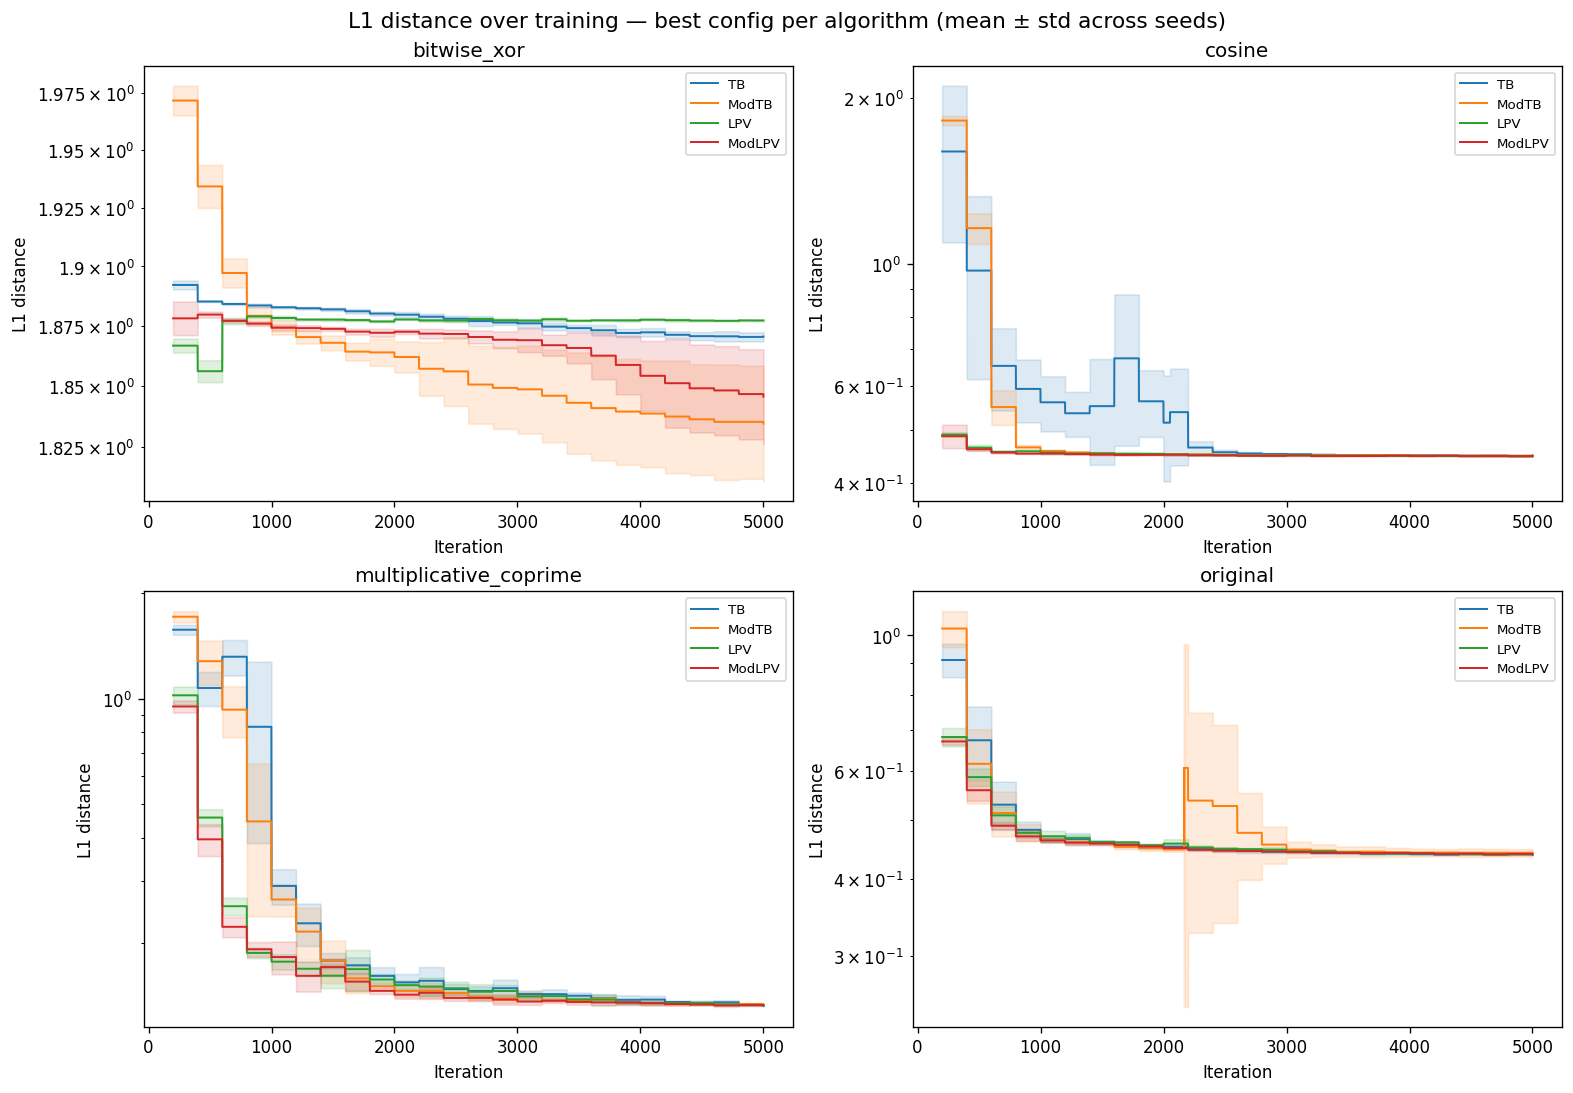

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        ad = ts_best[(ts_best["environment"] == env) & (ts_best["algo"] == algo)].copy()
        if ad.empty:
            continue
        ad = ad[ad["l1_finite"].notna()]
        if ad.empty:
            continue
        # Aggregate across seeds
        grouped = ad.groupby("iteration")["l1_finite"].agg(["mean", "std"])
        ax.plot(grouped.index, grouped["mean"], label=algo, color=COLORS[algo], linewidth=1.2)
        ax.fill_between(grouped.index,
                        grouped["mean"] - grouped["std"],
                        grouped["mean"] + grouped["std"],
                        color=COLORS[algo], alpha=0.15)
    ax.set_title(env)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("L1 distance")
    ax.set_yscale("log")
    ax.legend(loc="upper right")

fig.suptitle("L1 distance over training — best config per algorithm (mean ± std across seeds)", fontsize=13)
plt.show()

## Mode discovery over training (best-L1 runs)

Percentage of modes found over training for the same best-L1 runs selected above, relative to the total number of mode states in each environment.

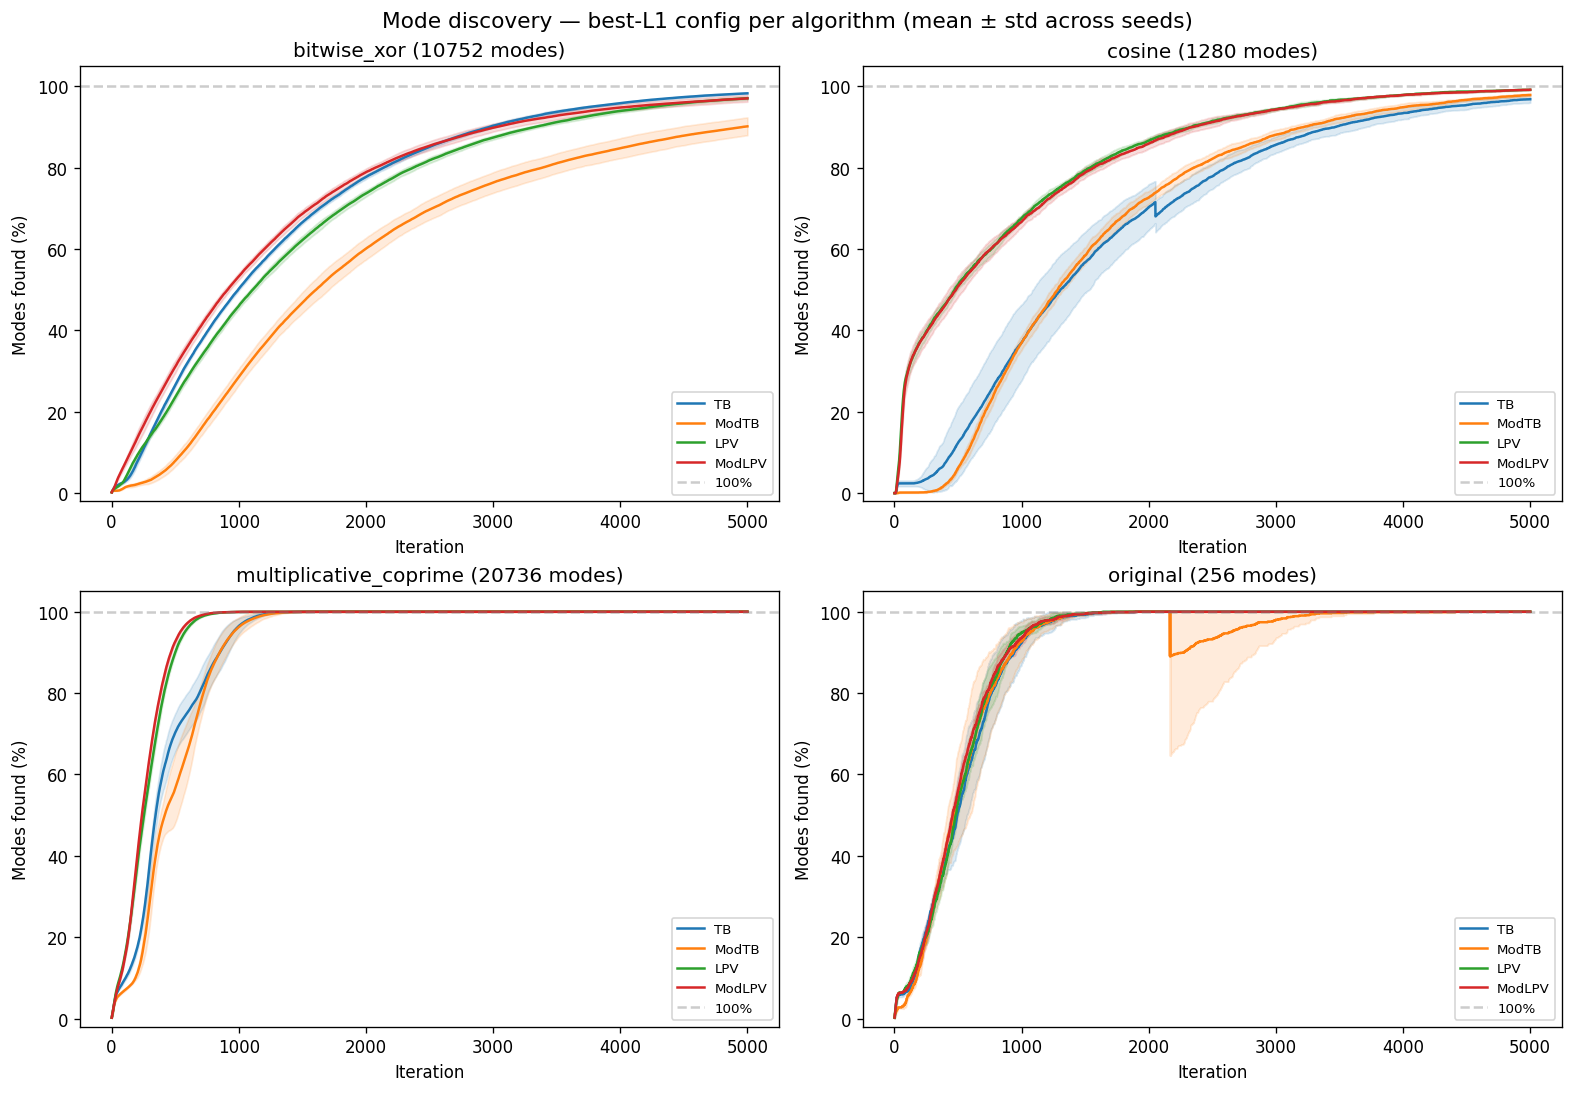

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    # Get total mode states for this environment
    env_data = ts_best[ts_best["environment"] == env]
    total_modes = env_data["total_mode_states"].dropna().iloc[0] if not env_data.empty else None

    for algo in ALGO_ORDER:
        ad = env_data[env_data["algo"] == algo]
        if ad.empty:
            continue
        grouped = ad.groupby("iteration")["n_mode_states_found"].agg(["mean", "std"])
        if total_modes and total_modes > 0:
            pct_mean = grouped["mean"] / total_modes * 100
            pct_std = grouped["std"] / total_modes * 100
        else:
            pct_mean = grouped["mean"]
            pct_std = grouped["std"]
        ax.plot(grouped.index, pct_mean, label=algo, color=COLORS[algo], linewidth=1.5)
        ax.fill_between(grouped.index,
                        (pct_mean - pct_std).clip(lower=0),
                        (pct_mean + pct_std).clip(upper=100),
                        color=COLORS[algo], alpha=0.15)
    ax.axhline(100, ls="--", color="gray", alpha=0.4, label="100%")
    title_suffix = f" ({int(total_modes)} modes)" if total_modes else ""
    ax.set_title(f"{env}{title_suffix}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Modes found (%)")
    ax.set_ylim(-2, 105)
    ax.legend(loc="lower right")

fig.suptitle("Mode discovery — best-L1 config per algorithm (mean ± std across seeds)", fontsize=13)
plt.show()

## Loss over training (best-L1 runs)

Loss values are not directly comparable across methods (different constructions), but shown for reference alongside the same best-L1 runs.

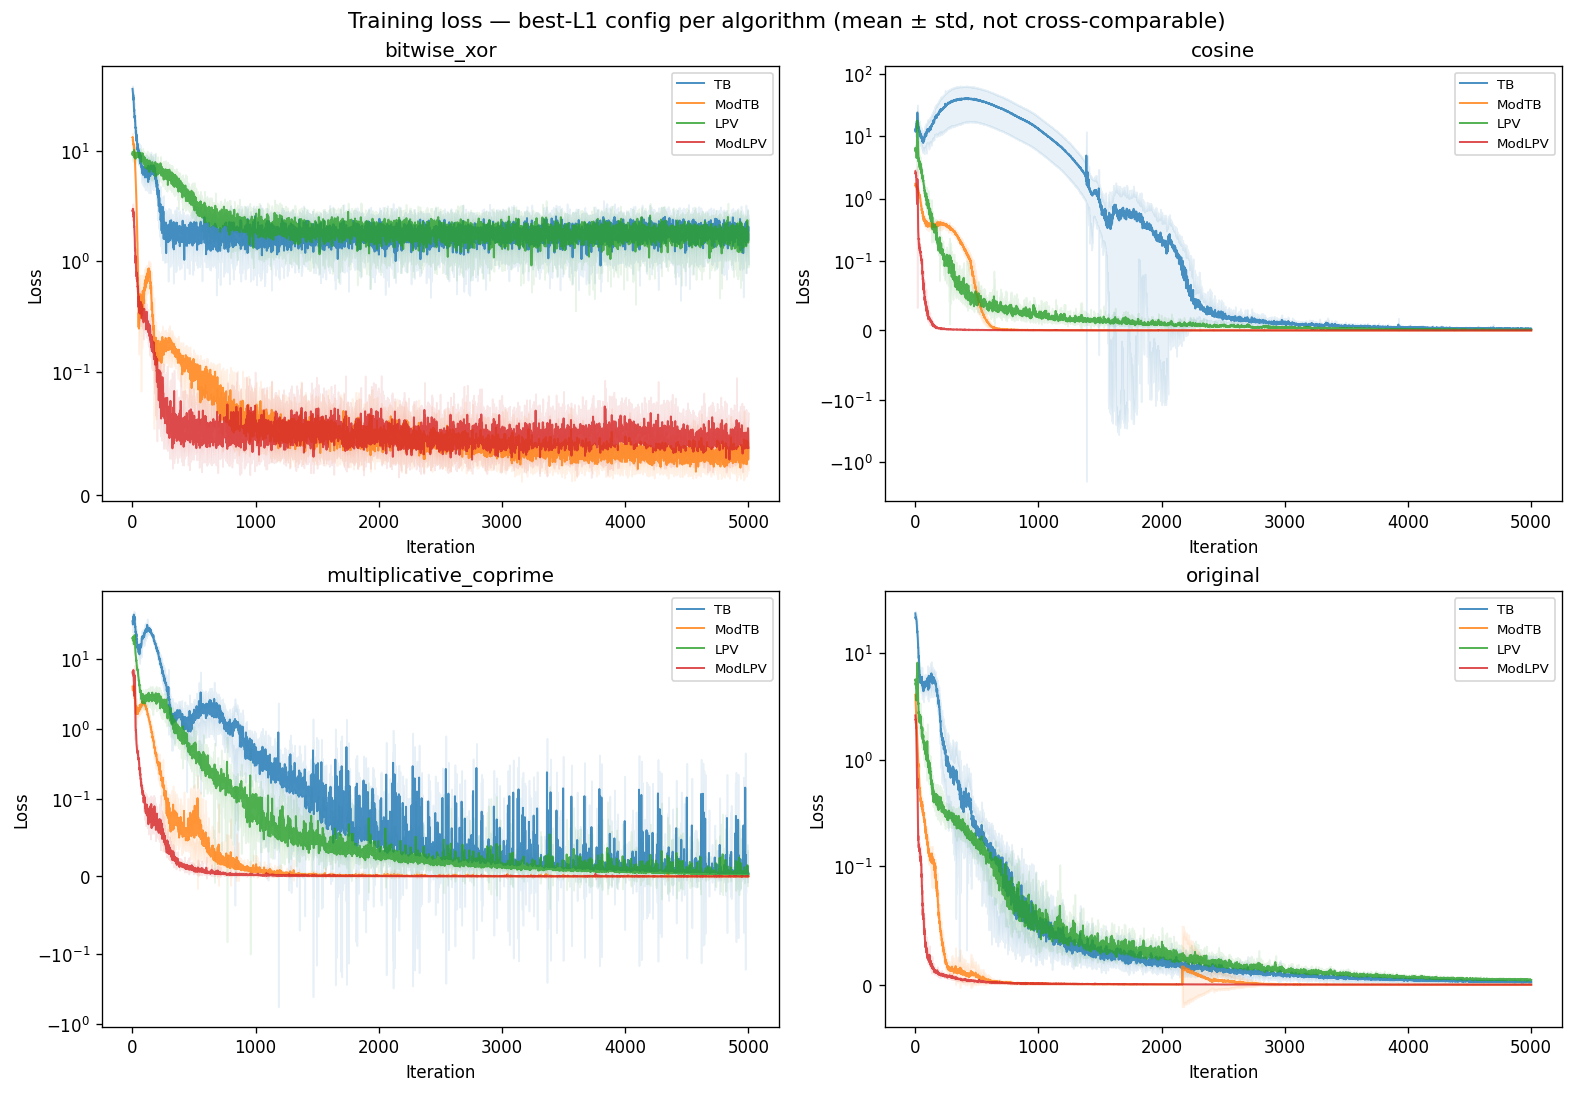

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        ad = ts_best[(ts_best["environment"] == env) & (ts_best["algo"] == algo)]
        if ad.empty:
            continue
        grouped = ad.groupby("iteration")["loss"].agg(["mean", "std"])
        clipped_mean = grouped["mean"].clip(upper=200)
        ax.plot(grouped.index, clipped_mean,
                label=algo, color=COLORS[algo], linewidth=1.2, alpha=0.8)
        ax.fill_between(grouped.index,
                        (clipped_mean - grouped["std"]).clip(lower=-200),
                        (clipped_mean + grouped["std"]).clip(upper=200),
                        color=COLORS[algo], alpha=0.1)
    ax.set_title(env)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_yscale("symlog", linthresh=0.1)
    ax.legend(loc="upper right")

fig.suptitle("Training loss — best-L1 config per algorithm (mean ± std, not cross-comparable)", fontsize=13)
plt.show()

## Hyperparameter sensitivity

For each algorithm, how does the best-case L1 distance vary with each hyperparameter? Each point = best run at that HP value (min across other HP settings).

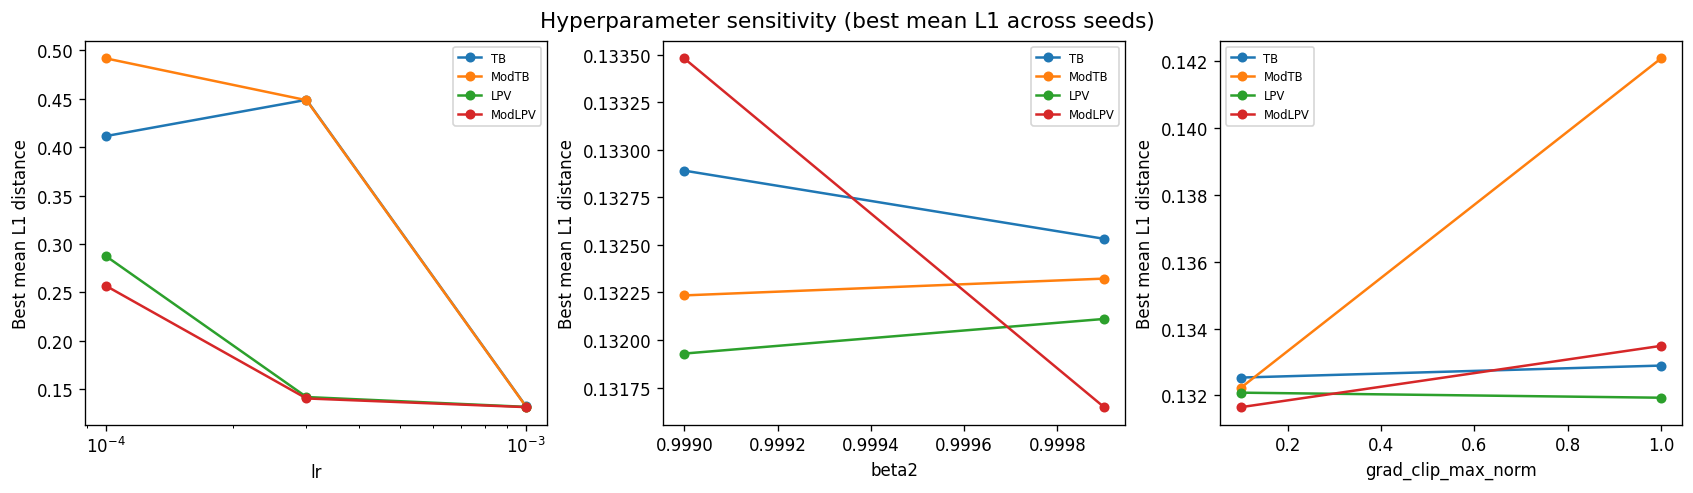

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, hp in zip(axes, HP_COLS):
    for algo in ALGO_ORDER:
        sub = config_stats[config_stats["algo"] == algo]
        if sub.empty or sub[hp].isna().all():
            continue
        grouped = sub.groupby(hp)["mean_l1"].min()
        ax.plot(grouped.index, grouped.values, "o-", label=algo, color=COLORS[algo], markersize=5)
    ax.set_xlabel(hp)
    ax.set_ylabel("Best mean L1 distance")
    if hp == "lr":
        ax.set_xscale("log")
    ax.legend(fontsize=7)

fig.suptitle("Hyperparameter sensitivity (best mean L1 across seeds)", fontsize=13)
plt.show()

## Best hyperparameters per algorithm x environment

In [8]:
best_detail = best_configs[["algo", "environment", "mean_l1", "std_l1", "n_seeds"] + HP_COLS].copy()
best_detail = best_detail.sort_values(["environment", "mean_l1"])
best_detail.style.format(
    {"mean_l1": "{:.4f}", "std_l1": "{:.4f}", "lr": "{:.0e}", "n_seeds": "{:.0f}"}, na_rep="—"
).background_gradient(subset=["mean_l1"], cmap="RdYlGn_r")

,algo,environment,mean_l1,std_l1,n_seeds,lr,beta2,grad_clip_max_norm
2,ModTB,bitwise_xor,1.8343,0.0236,5,1e-03,0.999000,1.000000
1,ModLPV,bitwise_xor,1.8455,0.0192,5,1e-03,0.999900,1.000000
0,LPV,bitwise_xor,1.8561,0.0046,5,1e-04,0.999900,1.000000
3,TB,bitwise_xor,1.8701,0.0020,5,1e-04,0.999000,0.100000
5,ModLPV,cosine,0.4474,0.0007,5,1e-03,0.999900,0.100000
4,LPV,cosine,0.4474,0.0007,5,1e-03,0.999000,1.000000
7,TB,cosine,0.4480,0.0004,5,1e-03,0.999900,0.100000
6,ModTB,cosine,0.4485,0.0003,5,3e-04,0.999000,0.100000
9,ModLPV,multiplicative_coprime,0.1316,0.0006,5,1e-03,0.999900,0.100000
8,LPV,multiplicative_coprime,0.1321,0.0006,5,1e-03,0.999000,0.100000


## Training stability: ModLPV vs LPV

ModLPV exhibits loss spikes during training, especially at higher learning rates. The instability is predominantly lr-driven — at lr <= 1e-4, ModLPV is comparably stable to LPV.

In [ ]:
# Compute rolling coefficient of variation (std/mean) over 100-iter windows
def _rolling_cv(g):
    loss = g.sort_values("iteration")["loss"]
    rm = loss.rolling(100, min_periods=20).mean()
    rs = loss.rolling(100, min_periods=20).std()
    return (rs / rm.clip(lower=1e-8)).mean()

stability = (
    ts[ts["algo"].isin(["ModLPV", "LPV", "ModTB", "TB"])]
    .groupby(["algo", "environment", "seed"] + HP_COLS)
    .apply(_rolling_cv, include_groups=False)
    .reset_index(name="cv")
)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.2], hspace=0.32, wspace=0.08)

# Top row: boxplot spanning all 4 columns
ax_box = fig.add_subplot(gs[0, :])
algos = ["TB", "ModTB", "LPV", "ModLPV"]
lr_vals = sorted(stability["lr"].unique())
n_algos = len(algos)
n_lrs = len(lr_vals)
group_width = 0.7
box_width = group_width / n_algos
offsets = np.linspace(-group_width/2 + box_width/2, group_width/2 - box_width/2, n_algos)

for ai, algo in enumerate(algos):
    sub = stability[stability["algo"] == algo]
    bp_data = [sub.loc[sub["lr"] == lr, "cv"].dropna().values for lr in lr_vals]
    positions = np.arange(n_lrs) + offsets[ai]
    bp = ax_box.boxplot(bp_data, positions=positions,
                        widths=box_width * 0.85, patch_artist=True, showfliers=False,
                        boxprops=dict(facecolor=COLORS[algo], alpha=0.4),
                        medianprops=dict(color="black"))
    ax_box.plot([], [], color=COLORS[algo], label=algo, linewidth=5, alpha=0.4)

ax_box.set_xticks(range(n_lrs))
ax_box.set_xticklabels([f"{lr:.0e}" for lr in lr_vals])
ax_box.set_xlabel("Learning rate")
ax_box.set_ylabel("Rolling CV of loss (instability)")
ax_box.legend(loc="upper left", ncol=4)
ax_box.set_title("Stability by learning rate")

# Bottom row: best-config loss curves with individual seed traces
for col, env in enumerate(env_list):
    ax = fig.add_subplot(gs[1, col])
    for algo in ALGO_ORDER:
        ad = ts_best[(ts_best["environment"] == env) & (ts_best["algo"] == algo)]
        if ad.empty:
            continue
        color = COLORS[algo]
        # Individual seed traces (thin, transparent)
        for seed in ad["seed"].unique():
            seed_data = ad[ad["seed"] == seed].sort_values("iteration")
            ax.plot(seed_data["iteration"], seed_data["loss"],
                    color=color, linewidth=0.4, alpha=0.3)
        # Mean line (solid)
        grouped = ad.groupby("iteration")["loss"].agg(["mean", "std"])
        ax.plot(grouped.index, grouped["mean"], label=algo,
                color=color, linewidth=1.5, alpha=0.9)
        # Std band
        ax.fill_between(grouped.index,
                         grouped["mean"] - grouped["std"],
                         grouped["mean"] + grouped["std"],
                         color=color, alpha=0.1)
    ax.set_xlabel("Iteration")
    if col == 0:
        ax.set_ylabel("Loss")
    else:
        ax.set_yticklabels([])
    ax.set_yscale("symlog", linthresh=0.01)
    ax.set_title(env)
    if col == 0:
        ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Training stability comparison", fontsize=14)
plt.show()

## L1 distance vs mode coverage: Pareto tradeoffs

Each point represents one hyperparameter configuration (averaged across seeds). This reveals whether there is a fundamental tradeoff between L1 distance and mode discovery, and whether certain algorithms dominate others across both objectives. Configs that were selected as "best-L1" in earlier plots are marked — note how they often sacrifice mode coverage. The Pareto frontier (lower-left is better on both axes) shows which configs are non-dominated.

In [ ]:
# --- Compute per-config mode coverage (final iteration, averaged across seeds) ---
final_iter = ts.groupby(CONFIG_COLS + ["seed"]).tail(1).copy()
final_iter["mode_pct"] = final_iter["n_mode_states_found"] / final_iter["total_mode_states"] * 100
mode_stats = (
    final_iter.groupby(CONFIG_COLS)["mode_pct"]
    .agg(mean_mode="mean", std_mode="std")
    .reset_index()
)
# Merge with L1 config stats
pareto_df = config_stats.merge(mode_stats, on=CONFIG_COLS)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, env in zip(axes.flat, env_list):
    env_df = pareto_df[pareto_df["environment"] == env]
    env_best = best_configs[best_configs["environment"] == env]

    for algo in ALGO_ORDER:
        sub = env_df[env_df["algo"] == algo]
        if sub.empty:
            continue
        ax.scatter(sub["mean_l1"], sub["mean_mode"], label=algo,
                   color=COLORS[algo], alpha=0.5, s=40, edgecolors="none")
        # Mark best-L1 config with a star
        best_row = env_best[env_best["algo"] == algo]
        if not best_row.empty:
            bm = sub.merge(best_row[HP_COLS], on=HP_COLS, how="inner")
            if not bm.empty:
                ax.scatter(bm["mean_l1"], bm["mean_mode"], marker="*",
                           color=COLORS[algo], s=200, edgecolors="black", linewidths=0.5, zorder=5)

    # Pareto frontier (across all algos)
    all_pts = env_df[["mean_l1", "mean_mode"]].dropna()
    if not all_pts.empty:
        pts = all_pts.sort_values("mean_l1").values
        pareto = [pts[0]]
        for p in pts[1:]:
            if p[1] >= pareto[-1][1]:  # higher mode coverage at higher L1 = new Pareto point
                pareto.append(p)
        pareto = np.array(pareto)
        ax.step(pareto[:, 0], pareto[:, 1], where="post", color="gray",
                linestyle="--", alpha=0.5, linewidth=1, label="Pareto frontier")

    ax.set_title(env)
    ax.set_xlabel("Mean L1 distance (lower = better)")
    ax.set_ylabel("Mode coverage % (higher = better)")
    ax.legend(fontsize=7, loc="lower left")

fig.suptitle("L1 distance vs mode coverage — all configs (★ = best-L1 config)", fontsize=13)
plt.show()

## Config selection bias: best-L1 vs best-mode-coverage

Earlier plots show mode coverage for configs selected by best L1 distance. But the config that minimizes L1 is often not the one that maximizes mode coverage. This plot compares, for each algorithm and environment: what mode coverage do you get from the best-L1 config vs the best-mode-coverage config? The gap between the two bars quantifies how much mode coverage is left on the table by optimizing for L1 alone. A second row shows the reverse: how much L1 is sacrificed by the best-mode config.

In [ ]:
# --- Best-mode configs ---
mode_config_stats = (
    final_iter.groupby(CONFIG_COLS)["mode_pct"]
    .agg(mean_mode="mean", std_mode="std")
    .reset_index()
)
best_mode_configs = (
    mode_config_stats.sort_values("mean_mode", ascending=False)
    .groupby(["environment", "algo"]).first().reset_index()
)

# Cross-reference: get mode coverage for best-L1 configs, and L1 for best-mode configs
best_l1_with_mode = best_configs.merge(
    pareto_df[CONFIG_COLS + ["mean_mode", "std_mode"]],
    on=CONFIG_COLS, how="left"
)
best_mode_with_l1 = best_mode_configs.merge(
    config_stats[CONFIG_COLS + ["mean_l1", "std_l1"]],
    on=CONFIG_COLS, how="left"
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

x = np.arange(len(ALGO_ORDER))
bar_w = 0.35

# Top row: mode coverage comparison
for col, env in enumerate(env_list):
    ax = axes[0, col]
    l1_modes = []
    mode_modes = []
    for algo in ALGO_ORDER:
        row_l1 = best_l1_with_mode[(best_l1_with_mode["environment"] == env) &
                                    (best_l1_with_mode["algo"] == algo)]
        row_mode = best_mode_configs[(best_mode_configs["environment"] == env) &
                                      (best_mode_configs["algo"] == algo)]
        l1_modes.append(row_l1["mean_mode"].values[0] if not row_l1.empty else 0)
        mode_modes.append(row_mode["mean_mode"].values[0] if not row_mode.empty else 0)

    bars1 = ax.bar(x - bar_w/2, l1_modes, bar_w, label="Best-L1 config",
                   color=[COLORS[a] for a in ALGO_ORDER], alpha=0.5, edgecolor="black", linewidth=0.5)
    bars2 = ax.bar(x + bar_w/2, mode_modes, bar_w, label="Best-mode config",
                   color=[COLORS[a] for a in ALGO_ORDER], alpha=1.0, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(ALGO_ORDER, fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_title(env, fontsize=10)
    if col == 0:
        ax.set_ylabel("Mode coverage %")
        ax.legend(fontsize=7)

# Bottom row: L1 comparison
for col, env in enumerate(env_list):
    ax = axes[1, col]
    l1_l1s = []
    mode_l1s = []
    for algo in ALGO_ORDER:
        row_l1 = best_configs[(best_configs["environment"] == env) &
                               (best_configs["algo"] == algo)]
        row_mode = best_mode_with_l1[(best_mode_with_l1["environment"] == env) &
                                      (best_mode_with_l1["algo"] == algo)]
        l1_l1s.append(row_l1["mean_l1"].values[0] if not row_l1.empty else 0)
        mode_l1s.append(row_mode["mean_l1"].values[0] if not row_mode.empty else 0)

    ax.bar(x - bar_w/2, l1_l1s, bar_w, label="Best-L1 config",
           color=[COLORS[a] for a in ALGO_ORDER], alpha=0.5, edgecolor="black", linewidth=0.5)
    ax.bar(x + bar_w/2, mode_l1s, bar_w, label="Best-mode config",
           color=[COLORS[a] for a in ALGO_ORDER], alpha=1.0, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(ALGO_ORDER, fontsize=8)
    ax.set_title(env, fontsize=10)
    if col == 0:
        ax.set_ylabel("Mean L1 distance")
        ax.legend(fontsize=7)

fig.suptitle("Config selection bias: best-L1 (faded) vs best-mode-coverage (solid)", fontsize=13)
plt.show()

## Algorithm ranking summary

No single algorithm dominates across all environments and metrics. This heatmap shows the rank (1 = best, 4 = worst) of each algorithm on three metrics — L1 distance, mode coverage, and training stability (rolling CV) — across all four environments. Green cells indicate strengths, red cells indicate weaknesses. The rightmost column shows the mean rank across all (environment, metric) combinations.

In [ ]:
# --- Compute ranks for each (algo, env) on three metrics ---
# 1. L1 distance (lower = better) — from best configs
l1_ranks = (
    best_configs.groupby("environment")["mean_l1"]
    .rank()
    .rename("L1")
)
l1_rank_df = best_configs[["algo", "environment"]].copy()
l1_rank_df["L1"] = l1_ranks.values

# 2. Mode coverage (higher = better) — best-mode configs
mode_rank_src = best_mode_configs[["algo", "environment", "mean_mode"]].copy()
mode_rank_src["Mode coverage"] = mode_rank_src.groupby("environment")["mean_mode"].rank(ascending=False)

# 3. Stability (lower CV = better) — median CV across all configs per algo
stability_median = (
    stability.groupby(["algo", "environment"])["cv"]
    .median()
    .reset_index(name="median_cv")
)
stability_median["Stability"] = stability_median.groupby("environment")["median_cv"].rank()

# Merge all ranks
rank_df = l1_rank_df.merge(
    mode_rank_src[["algo", "environment", "Mode coverage"]], on=["algo", "environment"]
).merge(
    stability_median[["algo", "environment", "Stability"]], on=["algo", "environment"]
)

# Pivot to (algo) x (env, metric)
metrics = ["L1", "Mode coverage", "Stability"]
rows = []
for algo in ALGO_ORDER:
    row = {"Algorithm": algo}
    for env in env_list:
        mask = (rank_df["algo"] == algo) & (rank_df["environment"] == env)
        for m in metrics:
            row[f"{env}\n{m}"] = rank_df.loc[mask, m].values[0] if mask.any() else np.nan
    rows.append(row)

heatmap_df = pd.DataFrame(rows).set_index("Algorithm")
heatmap_df["Mean rank"] = heatmap_df.mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 3.5), layout="constrained")

# Plot heatmap
data = heatmap_df.values
im = ax.imshow(data, cmap="RdYlGn_r", vmin=1, vmax=4, aspect="auto")

# Labels
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, fontsize=9, ha="center")
ax.set_yticks(range(len(ALGO_ORDER)))
ax.set_yticklabels(ALGO_ORDER, fontsize=11)

# Annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        text = f"{val:.1f}" if j == data.shape[1] - 1 else f"{int(val)}"
        ax.text(j, i, text, ha="center", va="center", fontsize=11,
                fontweight="bold" if val <= 1.5 else "normal",
                color="white" if val >= 3.5 else "black")

# Vertical separators between environments
for sep in [3, 6, 9]:
    ax.axvline(sep - 0.5, color="white", linewidth=2)
ax.axvline(11.5, color="gray", linewidth=2, linestyle="--")

plt.colorbar(im, ax=ax, label="Rank (1 = best, 4 = worst)", shrink=0.8, pad=0.02)
ax.set_title("Algorithm ranking: environment × metric (1 = best)", fontsize=13, pad=12)
plt.show()